## MNIST 손글씨 숫자 인식

In [1]:
import keras

# 3.10.0
keras.__version__

'3.10.0'

### MNIST 데이터셋 가져오기

In [2]:
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 탐색적 데이터 분석(EDA)

In [3]:
# train_images[0]
len(train_images)

60000

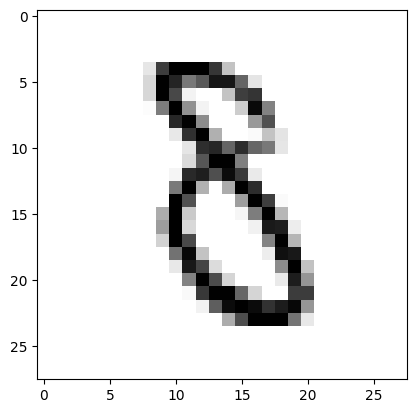

이미지의 클래스: 8


In [4]:
# train_images를 직접 matplotlib으로 그려서 이미지를 확인
# train_labels로 이미지의 클래스를 확인
import matplotlib.pyplot as plt
import random

# 랜덤으로 이미지 인덱스 선택
random_index = random.randint(0, len(train_images) - 1)

plt.imshow(train_images[random_index], cmap=plt.cm.binary)
plt.show()
print(f"이미지의 클래스: {train_labels[random_index]}")

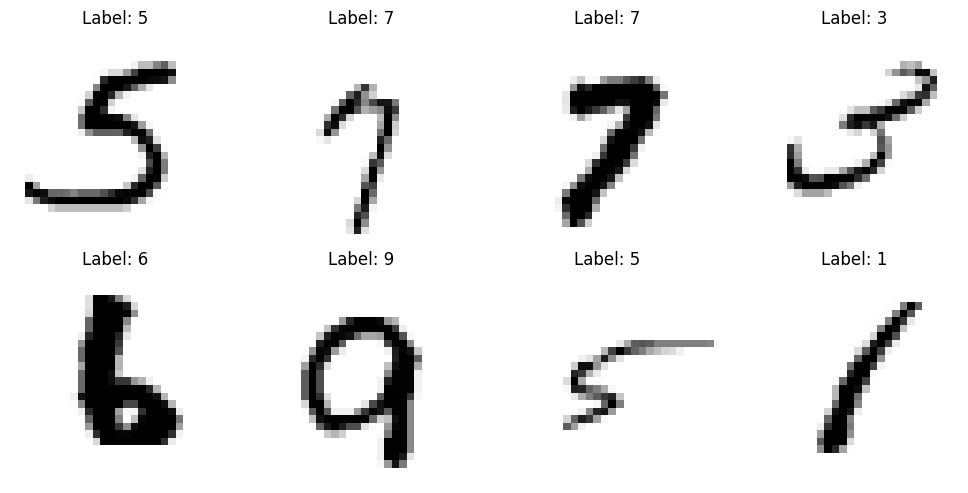

In [5]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10, 5))
for i in range(8):
    random_index = random.randint(0, len(train_images) - 1)
    plt.subplot(2, 4, i + 1)  # 2행 4열, i+1번째 서브플롯
    plt.imshow(train_images[random_index], cmap=plt.cm.binary)
    plt.title(f'Label: {train_labels[random_index]}')
    plt.axis('off') # 축 정보 숨기기
plt.tight_layout() # 서브플롯 간 간격 자동 조절
plt.show()

In [6]:
# 데이터의 갯수 확인
len(train_images), len(train_labels)

(60000, 60000)

In [7]:
# 훈련용 이미지, 레이블 데이터의 shape을 확인
train_images.shape, train_labels.shape

((60000, 28, 28), (60000,))

In [8]:
# 테스트용 이미지, 레이블 데이터의 shape을 확인
test_images.shape, test_labels.shape

((10000, 28, 28), (10000,))

In [9]:
# 0-255 사이의 정수 값. 현재 3차원 데이터 -> 2차원(reshape) 으로 변경해야 함.
test_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  84, 185, 159, 151,  60,  36,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 222, 254, 254, 254, 254, 241, 198,
        198, 198, 198, 198, 198, 198, 198, 170,  52,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  67, 114,  72, 114, 163, 227, 254,
        225, 254, 254, 254, 250, 229, 254, 254, 140,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  17,  66,
         14,  67,  67,  67,  59,  21, 236, 254, 106,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  83, 253, 209,  18,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  22, 233, 255,  83,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 129, 254, 238,  44,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  59, 249, 254,  62,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 133, 254, 187,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   9, 205, 248,  58,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 254, 182,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  75, 251, 240,  57,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         19, 221, 254, 166,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
        203, 254, 219,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38,
        254, 254,  77,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 224,
        254, 115,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 133, 254,
        254,  52,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

### 데이터 전처리
#### reshape (3차원 -> 2차원)
#### 정규화(Nomalize) 0-255 사이 숫자 -> 0-1 사이의 숫자 : 이미지는 무조건 이렇게 변환해야 함.

#### label을 one-hot encoding 변환

In [10]:
# reshape (NN에 입력하기 위해 3차원을 2차원으로 변환)
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))


In [11]:
train_images.shape, test_images.shape

((60000, 784), (10000, 784))

In [12]:
train_images[0][0]  # np.uint8(0) : int임

np.uint8(0)

In [13]:
# 정규화(Normalize)

train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255


In [14]:
train_images[0][0]  # np.float32(0.0) : float로 변경

np.float32(0.0)

In [15]:
train_labels[0] # np.uint8(5)

np.uint8(5)

In [16]:
# one-hot encoding 변환
from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


In [17]:
train_labels[0] #array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

### mnist를 keras로 모델링

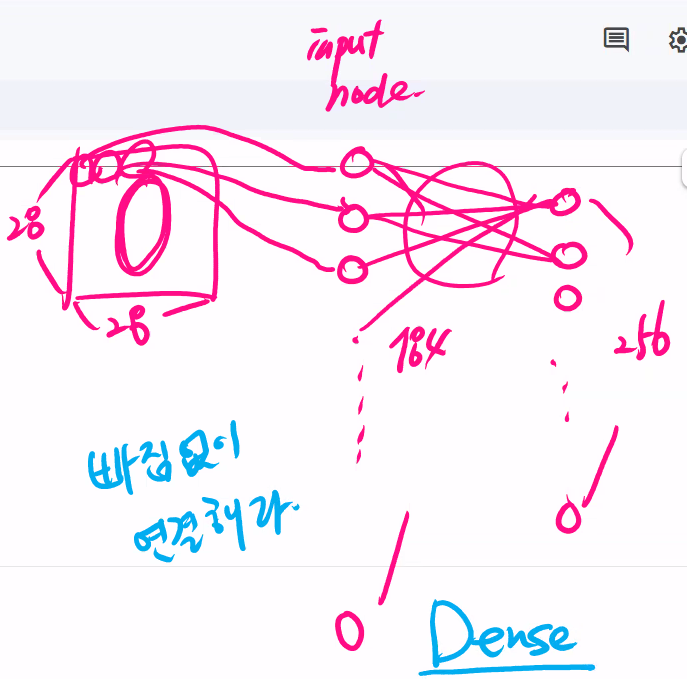

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
import numpy as np

# 신경망을 쌓아올리는 방식.
# 앞 레이어의 출력이 자동으로 다음 레이어의 입력으로 연결됨.
model = Sequential()

# 입력층(Input)을 정의
# model.add(Input(shape=(28, 28)))          #  -> 이걸 1차원으로 reshape해줘야 해.
model.add(Input(shape=(28*28,)))            # 2차원 -> 1차원 (28*28 = 784 input node)

# 은닉층(Hidden)을 정의. 레이어 2개.
model.add(Dense(256, activation='relu'))    # 그 다음 레이어의 노드 갯수 256
model.add(Dense(128, activation='relu'))    # 그 다음 레이어의 노드 갯수 128
# model.add(Dense(64, activation='relu'))    # 그 다음 레이어의 노드 갯수

# 레이어 노드 수를 512,256으로 키웠을 때 성능이 좋아지면 good. 아니면 굳이 숫자를 높일 필요 없음.

# 256, 128 -> Total params: 235,146
# 512, 256 ->  Total params: 535,818
# 512, 256, 64  ->  Total params: 550,346 (레이어 하나 더 추가)

# 출력층(Output)을 정의
# activation을 softmax로 사용
# 다중분류 모델의 출력값이 Logit(숫자)이 나옴 -> Logit을 확률로 변환해주는 함수 : softmax
model.add(Dense(10, activation='softmax'))  # 마지막 레이어의 노드 갯수 10 : 분류 클래스의 갯수 (0-9)

# 레이어 현황 보여줌
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

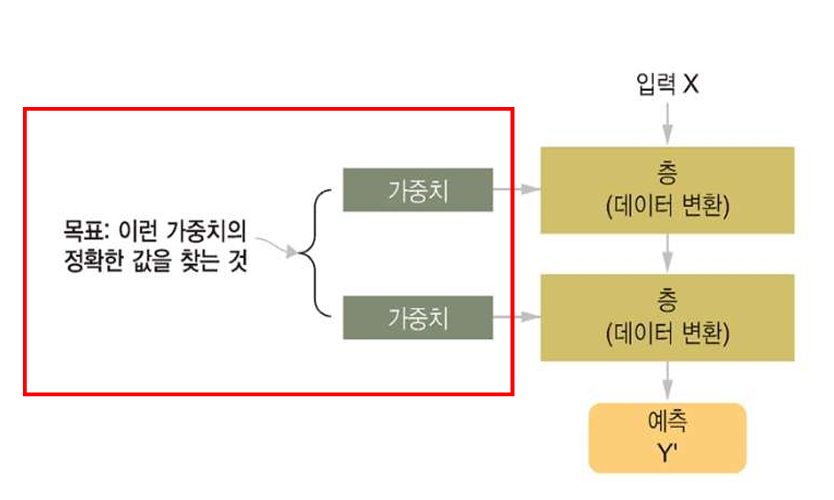

#### 모델을 설정(compile)

In [19]:
# loss 함수, optimizer함수, metrics(평가지표)를 정의, 설정
# 일반적으로 분류 모델에서는 loss, metrics를 사용. (matrix아님..matrics도 아님.. metrics!!)
# 회귀 모델에서는 loss만 사용하는 경우도 많다.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


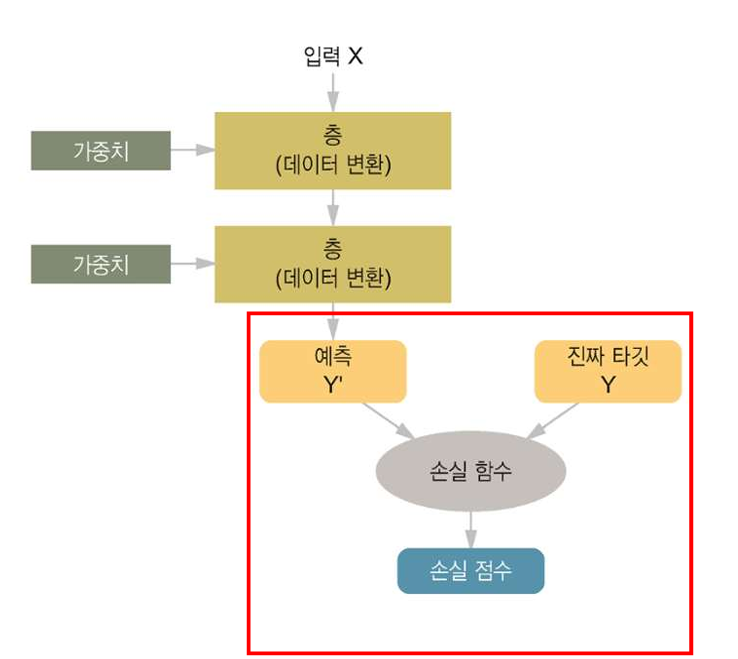

### 모델을 학습

In [20]:
# batch_size 보폭 한걸음 갈 때 256장 사용할거야.. 전체 6만장.
# 1에폭당 전체 234.xxx걸음 가는 것. 10 epoch시에 2350 걸음 이동
history = model.fit(train_images, train_labels, epochs=10, batch_size=256)
# history 변수에 담으면 에폭당 변화를 history에 로그 담아줘
# 일단 cpu로 돌려. 데이터 작으니까^^

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8235 - loss: 0.6265
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9564 - loss: 0.1452
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9732 - loss: 0.0879
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9826 - loss: 0.0592
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9862 - loss: 0.0457
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9894 - loss: 0.0350
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9903 - loss: 0.0297
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9937 - loss: 0.0226
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9942 - loss: 0.0196
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9962 - loss: 0.0140


In [21]:
history.history

{'accuracy': [0.9022666811943054,
  0.9614333510398865,
  0.9742666482925415,
  0.9813500046730042,
  0.985883355140686,
  0.9889166951179504,
  0.9903166890144348,
  0.9929500222206116,
  0.9945833086967468,
  0.9958833456039429],
 'loss': [0.34279561042785645,
  0.13095812499523163,
  0.08469878882169724,
  0.061770107597112656,
  0.04634319618344307,
  0.03628169745206833,
  0.029968446120619774,
  0.023344166576862335,
  0.01856319047510624,
  0.014803927391767502]}

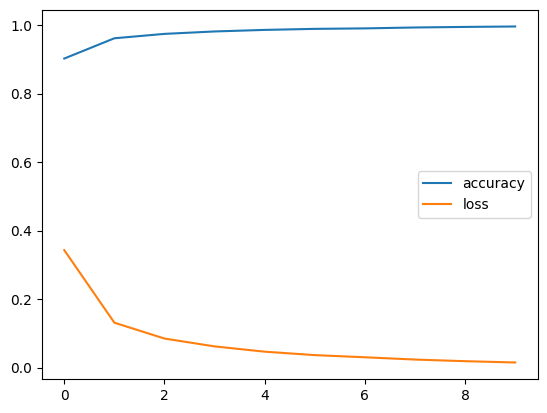

In [22]:
# history.history를 사용하여 그래프 출력

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.legend(['accuracy', 'loss'])
plt.show()

In [24]:
# test_images, test_labels를 사용하여 이미지의 클래스 예측
loss, accuracy = model.evaluate(test_images, test_labels)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9713 - loss: 0.1036
Test Loss: 0.0842
Test Accuracy: 0.9755
